In [124]:
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os
sys.path.append("/home/gc/workspace/drugPert/XPert")
os.chdir("/home/gc/workspace/drugPert/XPert")
os.getcwd()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


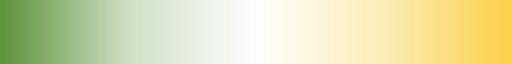

In [125]:
import matplotlib.colors as mcolors

cmap_colors = ['#FBD149', '#FDEDB7', '#FFFFFF', '#CFE0C5', '#5D933B'] 
cmap_colors = cmap_colors[::-1]
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', cmap_colors, N=256)
cmap

# Load adata

In [126]:
adata = sc.read_h5ad('processed_data/CDSDB_mdmt_613.h5ad')
adata

AnnData object with n_obs × n_vars = 613 × 978
    obs: 'Sample ID', 'Base/Post', 'CDS-DB patient signature list', 'CDS-DB dataset list', 'Patient ID', 'Sampling location', 'Sampling time', 'Annotation of the therapeutic regimen from the data source', 'Therapeutic Regimen Recorded In The Data Source', 'Therapeutic regimen', 'Therapeutic regimen ID', 'Administration dose', 'Additional information about the therapeutic regimen', 'Drug category', 'Source dataset', 'Source database', 'Reference (PubMed ID)', 'Data type', 'Platform', 'Cancer subtype recorded in the data source', 'Cancer subtype', 'DOID of cancer subtype', 'Sampling location category', 'Additional information about the cancer', 'Original response status', 'Response group', 'Pediatric oncology', 'Predefined grouping criteria of response and non-response groups', 'Drug category_compact', 'sample_id_unique', 'pair_match_id', 'pert_time', 'pert_time_idx', 'pert_dose', 'pert_dose_unit', 'pert_dose_idx', 'pert_id', 'pert_idx', 'ti

In [127]:
tissue = 'breast'
select_adata = adata[(adata.obs["Source dataset"] == "GSE20181") & (adata.obs["Response group"]!="unknown")]

select_adata

View of AnnData object with n_obs × n_vars = 102 × 978
    obs: 'Sample ID', 'Base/Post', 'CDS-DB patient signature list', 'CDS-DB dataset list', 'Patient ID', 'Sampling location', 'Sampling time', 'Annotation of the therapeutic regimen from the data source', 'Therapeutic Regimen Recorded In The Data Source', 'Therapeutic regimen', 'Therapeutic regimen ID', 'Administration dose', 'Additional information about the therapeutic regimen', 'Drug category', 'Source dataset', 'Source database', 'Reference (PubMed ID)', 'Data type', 'Platform', 'Cancer subtype recorded in the data source', 'Cancer subtype', 'DOID of cancer subtype', 'Sampling location category', 'Additional information about the cancer', 'Original response status', 'Response group', 'Pediatric oncology', 'Predefined grouping criteria of response and non-response groups', 'Drug category_compact', 'sample_id_unique', 'pair_match_id', 'pert_time', 'pert_time_idx', 'pert_dose', 'pert_dose_unit', 'pert_dose_idx', 'pert_id', 'pert_i

In [128]:
dataset_name = f"cdsdb_mdmt_{tissue}_GSE20181"
print(f"saveing to processed_data_infer/{dataset_name}.h5ad")
select_adata.write_h5ad(f'processed_data_infer/{dataset_name}.h5ad')

saveing to processed_data_infer/cdsdb_mdmt_breast_GSE20181.h5ad


# Obtain attention score

In [129]:
from datasets.MyDataset import MyDataset
from models.model_XPert_SNN import XPertNet_SNN
from metrics import get_metrics_infer

import torch
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
import yaml
import logging
import time
from argparse import Namespace

In [130]:
file_name = f"{tissue.split('_')[0]}_GSE20181"
expt_folder = f"experiment_snn_infer/plot_attn_cdsdb/{file_name}/" 
if not os.path.exists(expt_folder):
    os.makedirs(expt_folder)
timestamp = time.strftime('%Y%m%d_%H%M%S', time.localtime())

config_path = "configs/config_cdsdb.yaml"
with open(f'{config_path}', 'r') as f:
    config = yaml.safe_load(f)
print(config)


args = Namespace(
    mode="infer",
    nfold="split_1",
    drug_feat="unimol",
    device="cuda:1",
    model="XPert_SNN",
    config="config_cdsdb",
    fold=0,
    dataset=dataset_name,
    pretrained_mode="global",
    include_cell_idx=True,
    wo_HG=False,
    wo_atom=False,
    wo_gene_HG=False,
    wo_unimol=False,
    wo_ppi=False,
    use_gene_pos_emed=False,
    drug_pos_emb_type="learnable",
    wo_cell_loss=False,
    wo_pcc_loss=False,
    use_gradscaler=False,
    lr_scheduler=True,
    resume_from=None,
    saved_model_path="experiment_snn_cdsdb/split_warm",
    saved_model=None,
    pretrained_model=None,
    output_profile=False,
    output_attention=True,
    output_cls_embed=False,
    weighted_loss=False,
    kl_loss=False,
)

print(args)

{'model': {'XPert': None, 'ATTN': {'n_heads': 8, 'attention_probs_dropout_prob': 0.1, 'hidden_dropout_prob': 0.1, 'cell_input_hidden_dropout_prob': 0.1, 'drug_input_hidden_dropout_prob': 0.1, 'topk_cell': 128, 'topk_drug': 32, 'sparse_flag': False, 'hidden_size': 256, 'structure': 'CA+SA+SA+SA+SA+CA', 'trt_structure': 'CA+SA+SA+CA', 'ctl_structure': 'SA+SA+SA+SA', 'ppi_gene_vector_path': 'processed_data/PPI_gene_vector_128d.npy'}, 'HG': {'node_input_dim': 512, 'conv_layers': 2, 'hg_path': 'processed_data_HG_L1000/', 'drug_hg_pretrained_embed_path': 'processed_data_HG_L1000/HG_drug_embeddings_20241109_120917.npy', 'specific_pretrained_embed_path': None}, 'MDN': {'num_gaussians': 5, 'latent_size': 64}}, 'dataset': {'n_bins': 128, 'gene_num': 978, 'atom_num': 24, 'max_atom_size': 122, 'l1000': {'num_pert_dose': 10, 'num_pert_time': 3, 'num_cell_id': 240, 'num_tissue_id': 21}, 'panacea': {'num_pert_dose': 10, 'num_pert_time': 3, 'num_cell_id': 240, 'num_tissue_id': 21}, 'cdsdb': {'num_pert

In [131]:
args.dataset

'cdsdb_mdmt_breast_GSE20181'

In [132]:
# define logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG) # .DEBUG/INFO/WARNING/ERROR/CRITICAL
fh = logging.FileHandler(expt_folder+f'/{file_name}_{timestamp}.log')
fh.setLevel(logging.DEBUG)
logger.addHandler(fh)
ch = logging.StreamHandler()
ch.setLevel(logging.DEBUG)
logger.addHandler(ch)

In [133]:
def load_infer_dataloader(args,config,logger):

    batch_size = 1
    data = sc.read_h5ad(f'processed_data_infer/{args.dataset}.h5ad')
    drug_feat = np.load(config['dataset']['drug_unimol_path'], allow_pickle=True)

    test_data = data

    print(f'Test data:{test_data.n_obs}')

    if 'l1000' not in args.dataset:
        max_value = round(adata.X.max(),1)
        min_value = round(adata.X.min(),1)
        print(f'For dataset {args.dataset}, max_value:{max_value}, min_value:{min_value}')
    else:
        max_value, min_value = None, None

    print("Starting load infer data...")
    test_dataset = MyDataset(test_data, drug_feat, args=args, config=config, logger=logger, max_value=max_value, min_value=min_value)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=10, drop_last=False)

    print(f'Test dataloader:{len(test_dataloader)}')
    
    return test_dataloader


In [134]:
output_attention_branch = ["ctl"]
output_attention_layers = ["SA_0", "SA_1","SA_2", "SA_3"]
output_attention_mode = "mean_heads"

def infer(model, dataloader, args, config, flag=True, output_profile=False, scaler=None):
    model.eval()  
    trt_raw_data_ls = []
    output2_ls = []
    ctl_raw_data_ls = []
    pert_id_ls = []
    cell_id_ls = []
    pert_dose_ls = []
    pert_time_ls = []
    trt_attention_dict_ls= {}
    ctl_attention_dict_ls= {}
    cls_embed_ls = []


    with torch.no_grad():  

        for data in dataloader:
            trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned, drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx, pert_id, cell_id, pert_dose, pert_time = data

            if scaler:
                with autocast():
                    trt_output, ctl_output, output_deg, _, _, attention_dict, _, _, cls_embed= model((trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx))
            else:
                trt_output, ctl_output, output_deg, _, _, attention_dict, _, _, cls_embed = model((trt_raw_data, ctl_raw_data, trt_raw_data_binned, ctl_raw_data_binned,drug_feat, pert_dose_idx, pert_time_idx, drug_idx, cell_idx, tissue_idx))                     

            if flag:
                trt_raw_data_ls.append(trt_raw_data)
                output2_ls.append(output_deg.cpu()+ctl_raw_data)
                ctl_raw_data_ls.append(ctl_raw_data)
                if args.output_attention:
                    trt_attention_dict, ctl_attention_dict = attention_dict
                    if "trt" in output_attention_branch:
                        for key, value in trt_attention_dict.items():
                            # print(key, value.shape)
                            if key in output_attention_layers:
                                if key not in trt_attention_dict_ls:
                                    trt_attention_dict_ls[key] = []
                                trt_attention_dict_ls[key].append(value.mean(axis=1).mean(axis=1) if output_attention_mode=="mean_heads" else value)
                    if "ctl" in output_attention_branch:
                        for key, value in ctl_attention_dict.items():
                            if key in output_attention_layers:
                                if key not in ctl_attention_dict_ls:
                                    ctl_attention_dict_ls[key] = []
                                ctl_attention_dict_ls[key].append(value.mean(axis=1).mean(axis=1)[:, 1:] if output_attention_mode=="mean_heads" else value)

                if args.output_cls_embed:
                    cls_embed_ls.append(cls_embed)

                pert_id = list(drug_idx)
                cell_id = list(cell_id)
                pert_dose = list(pert_dose)
                pert_time = list(pert_time)

                pert_id_ls.extend(pert_id)
                cell_id_ls.extend(cell_id)
                pert_dose_ls.extend(pert_dose)
                pert_time_ls.extend(pert_time)


        if flag:
            y_true = torch.cat(trt_raw_data_ls, dim=0).cpu().detach().numpy()
            y_pred = torch.cat(output2_ls, dim=0).cpu().detach().numpy()
            ctl_true = torch.cat(ctl_raw_data_ls, dim=0).cpu().detach().numpy()
            metrics, metrics_all_ls = get_metrics_infer(y_true, y_pred, ctl_true)

            metrics_all_ls['pert_id'] = np.array(pert_id_ls)
            metrics_all_ls['cell_id'] = np.array(cell_id_ls)
            metrics_all_ls['pert_dose'] = np.array(pert_dose_ls)
            metrics_all_ls['pert_time'] = np.array(pert_time_ls)
        else:
            metrics = None
            metrics_all_ls = None

        
        
        # output attention
        all_attention_dict = None
        if args.output_attention:
            all_attention_dict = {}
            all_trt_attention_dict = {}
            all_ctl_attention_dict = {}
            if trt_attention_dict_ls != {}:
                for key, value in trt_attention_dict_ls.items():
                    all_trt_attention_dict[key] = torch.cat(value, dim=0).cpu().detach().numpy()
                all_attention_dict['trt'] = all_trt_attention_dict
            if ctl_attention_dict_ls != {}:
                for key, value in ctl_attention_dict_ls.items():
                    all_ctl_attention_dict[key] = torch.cat(value, dim=0).cpu().detach().numpy()
                all_attention_dict['ctl'] = all_ctl_attention_dict 

        # output cls_embed
        all_cls_embed = None
        if args.output_cls_embed:
            all_cls_embed = torch.cat(cls_embed_ls, dim=0).cpu().detach().numpy()

    
        if output_profile:
            output_pred_profile = {}
            output_pred_profile['y_true'] = y_true
            output_pred_profile['y_pred'] = y_pred
            output_pred_profile['ctl_true'] = ctl_true
            output_pred_profile['deg_true'] = y_true-ctl_true
            output_pred_profile['deg_pred'] = y_pred-ctl_true
        else:
            output_pred_profile = None

    return metrics, metrics_all_ls, output_pred_profile, all_attention_dict, all_cls_embed

In [135]:
test_dataloader = load_infer_dataloader(args, config, logger)
device = args.device
fold = "split"
model = XPertNet_SNN(args, config, device, logger)
model.to(device)

# load model
all_attention_dict = {}
for fold in [1,2,3,4,5]:
    print(f'=================== fold {fold} ===================')
    saved_model = f"{args.saved_model_path}/split_{fold}_fold_early_stop.pth"
    print(f'Loading model from {saved_model}')
    checkpoint = torch.load(saved_model)
    model_dict = model.state_dict()
    pretrained_dict = {k:v for k,v in checkpoint['model_state_dict'].items() if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)


    start_time = time.time()
    logger.info('Start testing  ... ')
    logger.info('Testing on test dataset:')
    test_metrics, test_metrics_all_ls, test_output_pred_profile, test_all_attention_dict, all_cls_embed = infer(model, test_dataloader, args, config, flag=True, output_profile=args.output_profile, scaler=args.use_gradscaler)

    logger.info(f"{int(time.time() - start_time)/60:.2f}mins")
    logger.info('Test Metrics:')
    logger.info(test_metrics)

    all_attention_dict[f"fold{fold}"] = test_all_attention_dict

binning process... n_bins:128
binning process... n_bins:128


Test data:102
For dataset cdsdb_mdmt_breast_GSE20181, max_value:16.0, min_value:1.9
Starting load infer data...


100%|██████████| 102/102 [00:00<00:00, 1115.45it/s]
For cell embedding: using ppi_gene_vector + exp embedding
For cell embedding: using ppi_gene_vector + exp embedding
Using dose and time embedding
Using dose and time embedding
Using sparse attn: False
Using sparse attn: False


Test dataloader:102


Using sparse attn: False
Using sparse attn: False


...

Start testing  ... 
Start testing  ... 
Testing on test dataset:
Testing on test dataset:
0.07mins
0.07mins
Test Metrics:
Test Metrics:
{'MSE': 0.063, 'RMSE': 0.252, 'MAE': 0.175, 'Pearson': 0.984, 'Spearman': 0.982, 'Precision@10 Positive': 1.0, 'Precision@10 Negative': 0.998, 'Precision@20 Positive': 0.997, 'Precision@20 Negative': 0.999, 'Precision@50 Positive': 0.985, 'Precision@50 Negative': 0.995, 'Precision@100 Positive': 0.884, 'Precision@100 Negative': 0.903, 'MSE_deg': 0.063, 'RMSE_deg': 0.252, 'MAE_deg': 0.175, 'Pearson_deg': 0.865, 'Spearman_deg': 0.823, 'Precision@10 Positive_deg': 0.947, 'Precision@10 Negative_deg': 0.95, 'Precision@20 Positive_deg': 0.934, 'Precision@20 Negative_deg': 0.937, 'Precision@50 Positive_deg': 0.851, 'Precision@50 Negative_deg': 0.87, 'Precision@100 Positive_deg': 0.68, 'Precision@100 Negative_deg': 0.701}
{'MSE': 0.063, 'RMSE': 0.252, 'MAE': 0.175, 'Pearson': 0.984, 'Spearman': 0.982, 'Precision@10 Positive': 1.0, 'Precision@10 Negative': 0.99

=================== fold 4 ===================
Loading model from experiment_snn_cdsdb/split_warm/split_4_fold_early_stop.pth


0.07mins
0.07mins
Test Metrics:
Test Metrics:
{'MSE': 0.058, 'RMSE': 0.241, 'MAE': 0.155, 'Pearson': 0.986, 'Spearman': 0.984, 'Precision@10 Positive': 0.994, 'Precision@10 Negative': 1.0, 'Precision@20 Positive': 0.993, 'Precision@20 Negative': 1.0, 'Precision@50 Positive': 0.985, 'Precision@50 Negative': 0.995, 'Precision@100 Positive': 0.896, 'Precision@100 Negative': 0.923, 'MSE_deg': 0.058, 'RMSE_deg': 0.241, 'MAE_deg': 0.155, 'Pearson_deg': 0.882, 'Spearman_deg': 0.856, 'Precision@10 Positive_deg': 0.925, 'Precision@10 Negative_deg': 0.944, 'Precision@20 Positive_deg': 0.917, 'Precision@20 Negative_deg': 0.933, 'Precision@50 Positive_deg': 0.888, 'Precision@50 Negative_deg': 0.895, 'Precision@100 Positive_deg': 0.735, 'Precision@100 Negative_deg': 0.752}
{'MSE': 0.058, 'RMSE': 0.241, 'MAE': 0.155, 'Pearson': 0.986, 'Spearman': 0.984, 'Precision@10 Positive': 0.994, 'Precision@10 Negative': 1.0, 'Precision@20 Positive': 0.993, 'Precision@20 Negative': 1.0, 'Precision@50 Positive':

=================== fold 5 ===================
Loading model from experiment_snn_cdsdb/split_warm/split_5_fold_early_stop.pth


0.07mins
0.07mins
Test Metrics:
Test Metrics:
{'MSE': 0.064, 'RMSE': 0.254, 'MAE': 0.163, 'Pearson': 0.984, 'Spearman': 0.983, 'Precision@10 Positive': 0.994, 'Precision@10 Negative': 1.0, 'Precision@20 Positive': 0.992, 'Precision@20 Negative': 0.999, 'Precision@50 Positive': 0.982, 'Precision@50 Negative': 0.995, 'Precision@100 Positive': 0.887, 'Precision@100 Negative': 0.915, 'MSE_deg': 0.064, 'RMSE_deg': 0.254, 'MAE_deg': 0.163, 'Pearson_deg': 0.883, 'Spearman_deg': 0.859, 'Precision@10 Positive_deg': 0.931, 'Precision@10 Negative_deg': 0.958, 'Precision@20 Positive_deg': 0.925, 'Precision@20 Negative_deg': 0.943, 'Precision@50 Positive_deg': 0.891, 'Precision@50 Negative_deg': 0.901, 'Precision@100 Positive_deg': 0.742, 'Precision@100 Negative_deg': 0.757}
{'MSE': 0.064, 'RMSE': 0.254, 'MAE': 0.163, 'Pearson': 0.984, 'Spearman': 0.983, 'Precision@10 Positive': 0.994, 'Precision@10 Negative': 1.0, 'Precision@20 Positive': 0.992, 'Precision@20 Negative': 0.999, 'Precision@50 Positi

In [136]:
test_all_attention_dict.keys(), test_all_attention_dict["ctl"].keys(), test_all_attention_dict["ctl"]["SA_0"].shape

(dict_keys(['ctl']), dict_keys(['SA_0', 'SA_1', 'SA_2', 'SA_3']), (102, 978))

In [137]:
all_attention_dict.keys()

dict_keys(['fold1', 'fold2', 'fold3', 'fold4', 'fold5'])

# Define visualization function

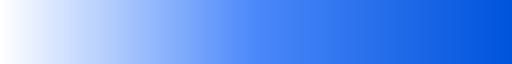

In [138]:
# define colormap
import matplotlib.colors as mcolors

colorlist = ["white", "#4B88FA", "#0054DC"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap", colorlist
)

custom_cmap

In [139]:
select_adata.obs["Response group"].value_counts()

Response group
Response        73
Non-response    29
Name: count, dtype: int64

In [140]:
from experiment_snn_infer.plot_attn_cdsdb.gene_attn_vis import plot_attention_boxplot, plot_attention_heatmap, plot_attention_scatter


def drawAttn(all_attn_dict, fold, layers, save_path=None, figsize=(18,6), random_seed=10):

    rng = np.random.default_rng(seed = random_seed)
    gene_idx = rng.choice(978, size=200, replace=False)

    print("gene_idx:", gene_idx)


    meta_df = select_adata.obs.copy()
    meta_df.reset_index(drop=True, inplace=True)
    response_idx = meta_df[meta_df["Response group"]=="Response"].index.values
    non_response_idx = meta_df[meta_df["Response group"]=="Non-response"].index.values
    sorted_idx = np.concatenate((response_idx, non_response_idx), axis=0)

    gene_attn_dict = {}
    res_gene_attn_mean_dict = {}
    non_gene_attn_mean_dict = {}
    for key in all_attn_dict.keys():
        attn_dict = all_attn_dict[key]["ctl"]
        if '+' not in layers:
            attn = attn_dict[layers]
            gene_attn = attn[sorted_idx]
            res_gene_attn_mean = attn[response_idx, :].mean(axis=0)
            non_gene_attn_mean = attn[non_response_idx, :].mean(axis=0)
        else:
            gene_attn_ls = []
            res_gene_attn_mean_ls = []
            non_gene_attn_mean_ls = []
            for layer in layers.split("+"):
                attn = attn_dict[layer]
                gene_attn = attn[sorted_idx]
                res_gene_attn_mean = attn[response_idx, :].mean(axis=0)
                non_gene_attn_mean = attn[non_response_idx, :].mean(axis=0)
                gene_attn_ls.append(gene_attn)
                res_gene_attn_mean_ls.append(res_gene_attn_mean)
                non_gene_attn_mean_ls.append(non_gene_attn_mean)
            gene_attn = np.array(gene_attn_ls).mean(axis=0)
            res_gene_attn_mean = np.array(res_gene_attn_mean_ls).mean(axis=0)
            non_gene_attn_mean = np.array(non_gene_attn_mean_ls).mean(axis=0)

        
        gene_attn_dict[key] = gene_attn
        res_gene_attn_mean_dict[key] = res_gene_attn_mean
        non_gene_attn_mean_dict[key] = non_gene_attn_mean

    fig, axes = plt.subplots(3, 1, figsize=(18,18), gridspec_kw={'height_ratios': [1, 1, 1]} )
    axes = axes.flatten()

    res_attention_mean_arr = np.array([res_gene_attn_mean_dict[f"fold{i}"] for i in range(1, 6)])
    non_attention_mean_arr = np.array([non_gene_attn_mean_dict[f"fold{i}"] for i in range(1, 6)])


    if fold == "mean":
        plot_attention_boxplot(gene_attn_dict[f"fold1"][:, gene_idx], save_path=None, ax=axes[0], palette="Spectral")
    else:
        plot_attention_boxplot(gene_attn_dict[f"fold{fold}"][:, gene_idx], save_path=None, ax=axes[0], palette="Spectral")    

    # plot scatter across seeds
    plot_attention_scatter(res_attention_mean_arr[:, gene_idx], cmap='Paired', ax=axes[1], title="Mean Gene Attention across Folds (Response Group)")
    plot_attention_scatter(non_attention_mean_arr[:, gene_idx], cmap='Paired', ax=axes[2], title="Mean Gene Attention across Folds (Non-Response Group)")

    # fig.suptitle(f'Attention Visualization for Genes', fontsize=24, y=1.02)
    # plt.tight_layout()

    plt.subplots_adjust(hspace=0.4)

    if save_path:
        fig.savefig(save_path, format="svg", dpi=300, bbox_inches='tight')
        print(f"Saving to: {save_path}")
    
    plt.show()

    return fig, (gene_attn_dict, res_gene_attn_mean_dict, non_gene_attn_mean_dict)

# Plot

gene_idx: [518 124  62 734 281 107 329 708 923 476 660 800 267 460  61 962 950 573
 737 433 795 426 781  92 256 385 404 965 209 604 665 367 450 128 117 507
 677 958 763 649  45 893 715 212 554  12 583 748 556 317 162 498 527 811
 676 403 863 177 326 320 243 338 601 428 396 935 970 325 700 462 897 271
 667 376 926 348 196 545 234 620  98 951 914 419 291 222  88 113 886 504
 612 668 955 311 417 307 745  52 755 681 114 109 304 861 206 120 185 380
 543 500 696 279 754 613 882 939 684 727 302 261  19 866 661 241  57 807
 505 473 779  42 593 912 407 221 768 217 205  18 732 100 429 759 739 720
  32 902   6 669 210 575 517 193 761 643 925 626 591 872 555 787 116  75
  93 265 489 579 310 423 741 892 756 188 701 168 918 147 655 414 969 633
 635  74 801 129 289 857 127 606 488 744 607 617 293 568 252 466 323 142
 327 600]


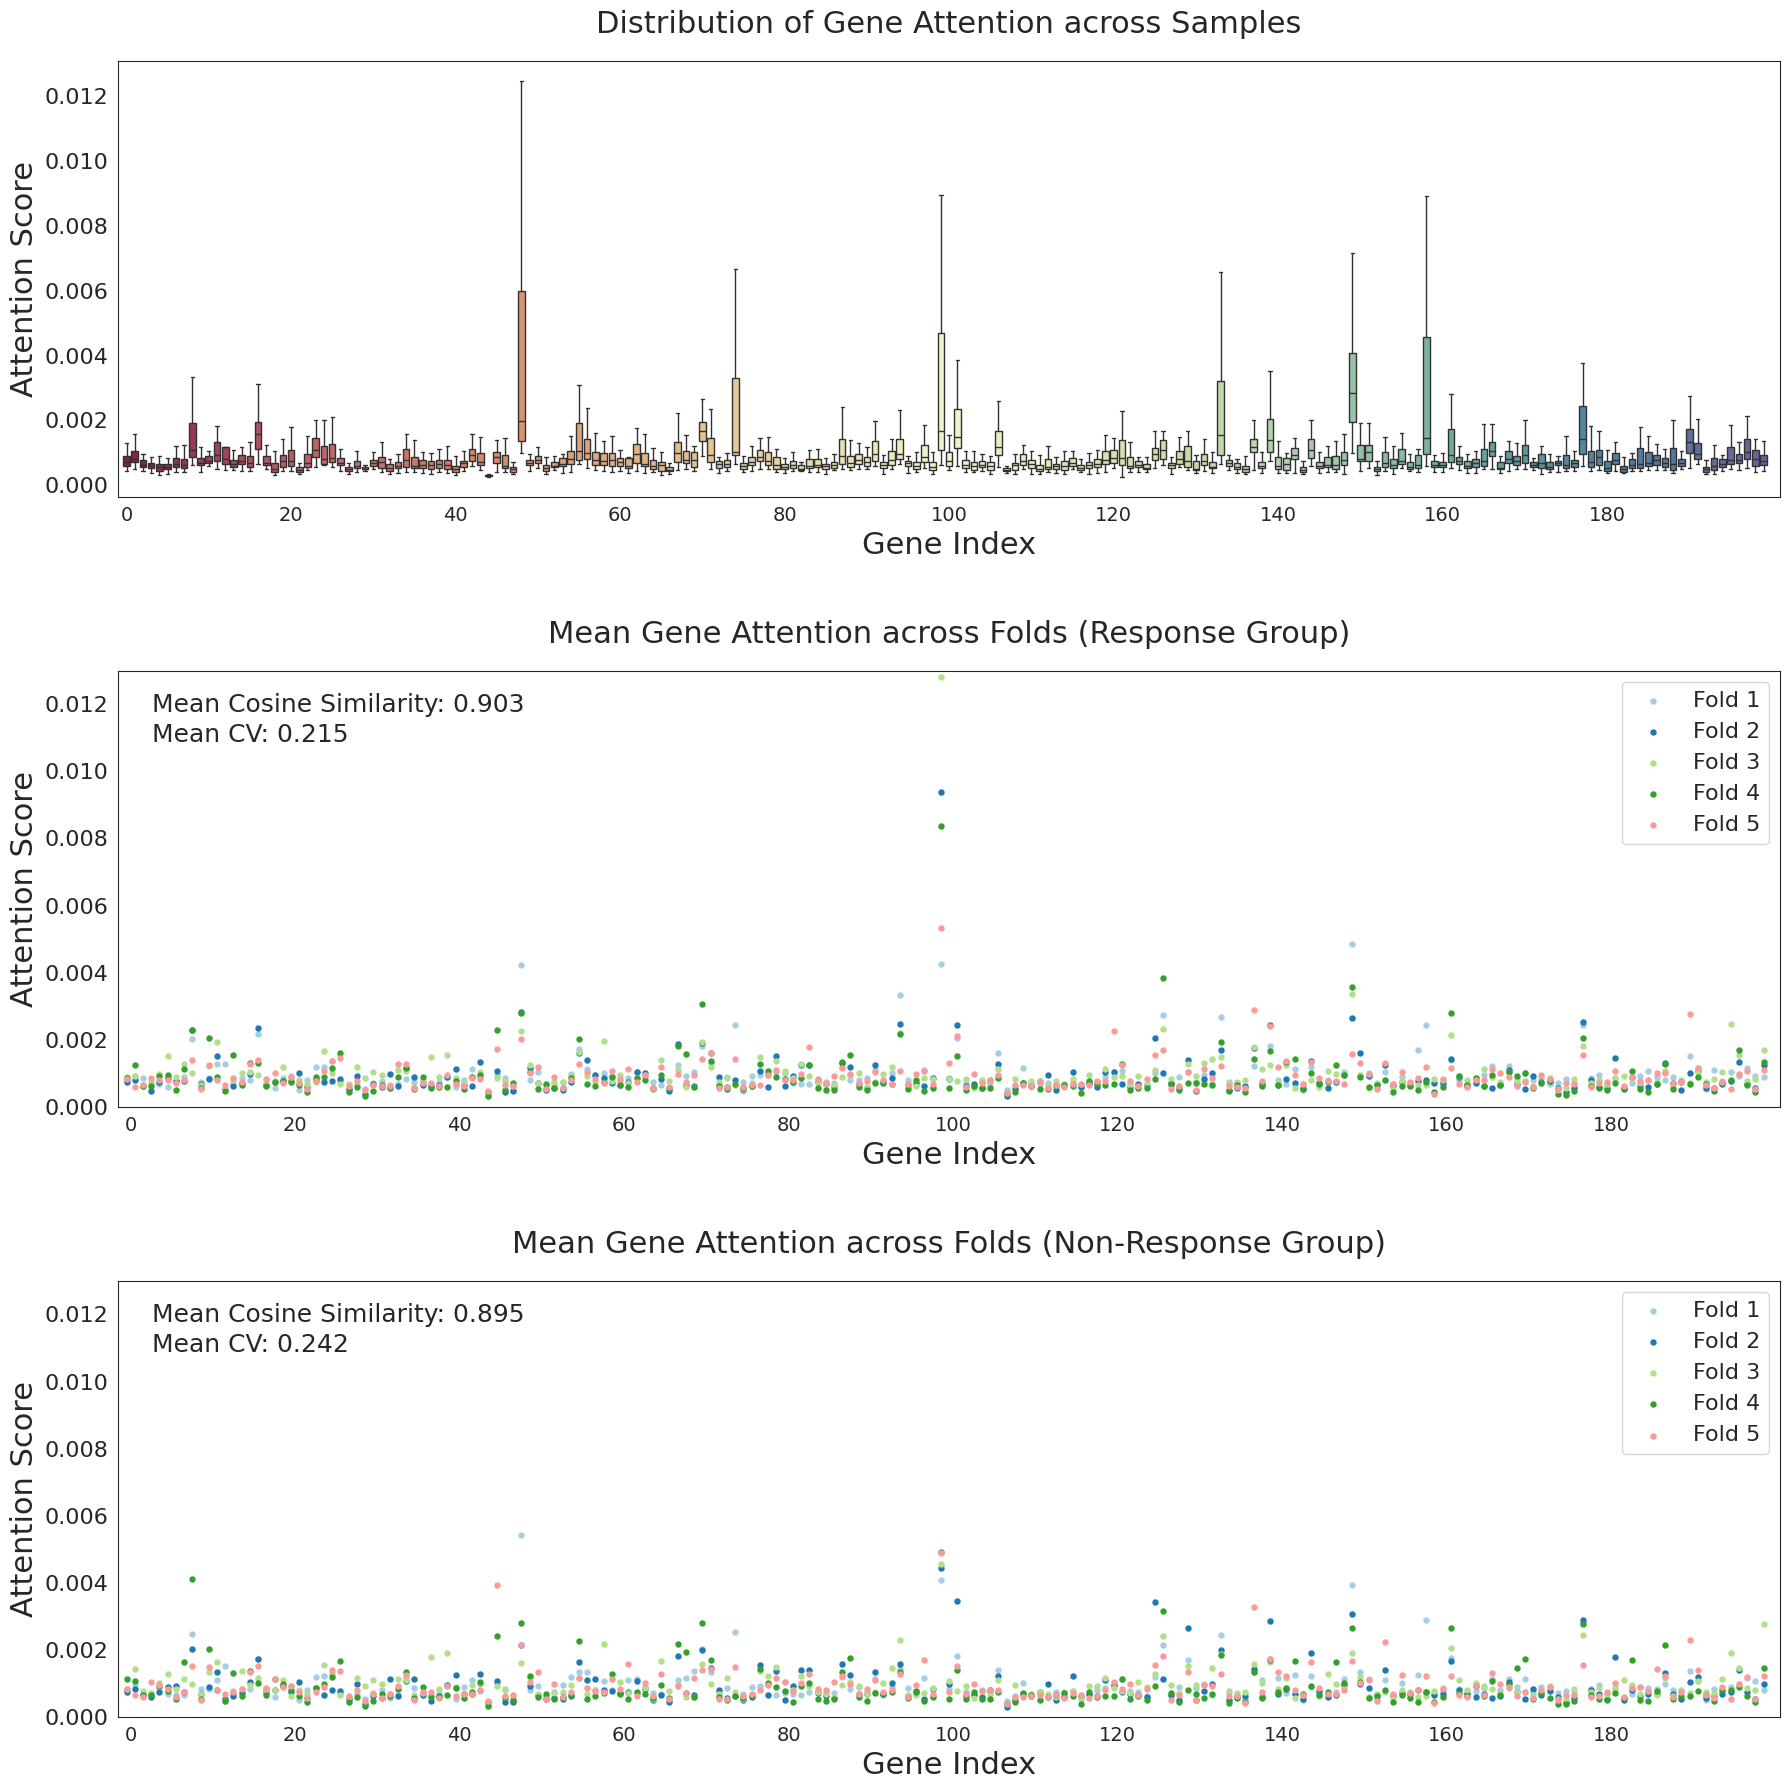

In [146]:
layers = 'SA_0+SA_1+SA_2+SA_3'
random_seed = 10

# for fold in [1,2,3,4,5]:
for fold in ["mean"]:    
    # save_path = f'{expt_folder}fold_{fold}_layer_{layers}_random_{random_seed}.svg'
    save_path = None
    fig, attn_dict = drawAttn(all_attention_dict, fold, layers, save_path=save_path, figsize=(18,6), random_seed=random_seed)

gene_attn_dict, res_gene_attn_mean_dict, non_gene_attn_mean_dict = attn_dict

# Differential Attention Analysis: non-response v.s. response

In [ ]:
from scipy import stats
from adjustText import adjust_text

def min_max_normalization(df):
    return (df - df.min()) / (df.max() - df.min())

select_adata = select_adata[select_adata.obs.sort_values(by='Response group', ascending=False).index,:]

def generate_df(attention_dict):
    
    attention_arr = np.array([attention_dict[f"fold{i}"] for i in range(1, 6)]).mean(axis=0)
    print("attention_arr.shape:", attention_arr.shape)

    response_num = select_adata.obs["Response group"].value_counts()["Response"]
    df = pd.DataFrame(attention_arr.T, index=select_adata.var_names, columns=select_adata.obs["Response group"])
     
    df = df*1000  # to reduce errors caused by numerical precision
    df['NON/RES'] = np.mean(df.values[:,response_num:],1)/np.mean(df.values[:,:response_num],1)
    df['P-value'] = [stats.ttest_ind(a,b)[1] for a,b in zip(df.values[:,response_num:], df.values[:,:response_num])]
    
    return df

In [144]:
pd_df = generate_df(gene_attn_dict)

attention_arr.shape: (102, 978)


                    x         y    group
gene_symbol                             
DDR1        -0.019212  0.278719  #C3C1C0
PAX8         0.395900  4.384213     grey
RPS5        -0.481685  3.443676  #C3C1C0
ABCF1       -0.316399  8.566070     grey
SPAG7        0.225396  5.262371     grey


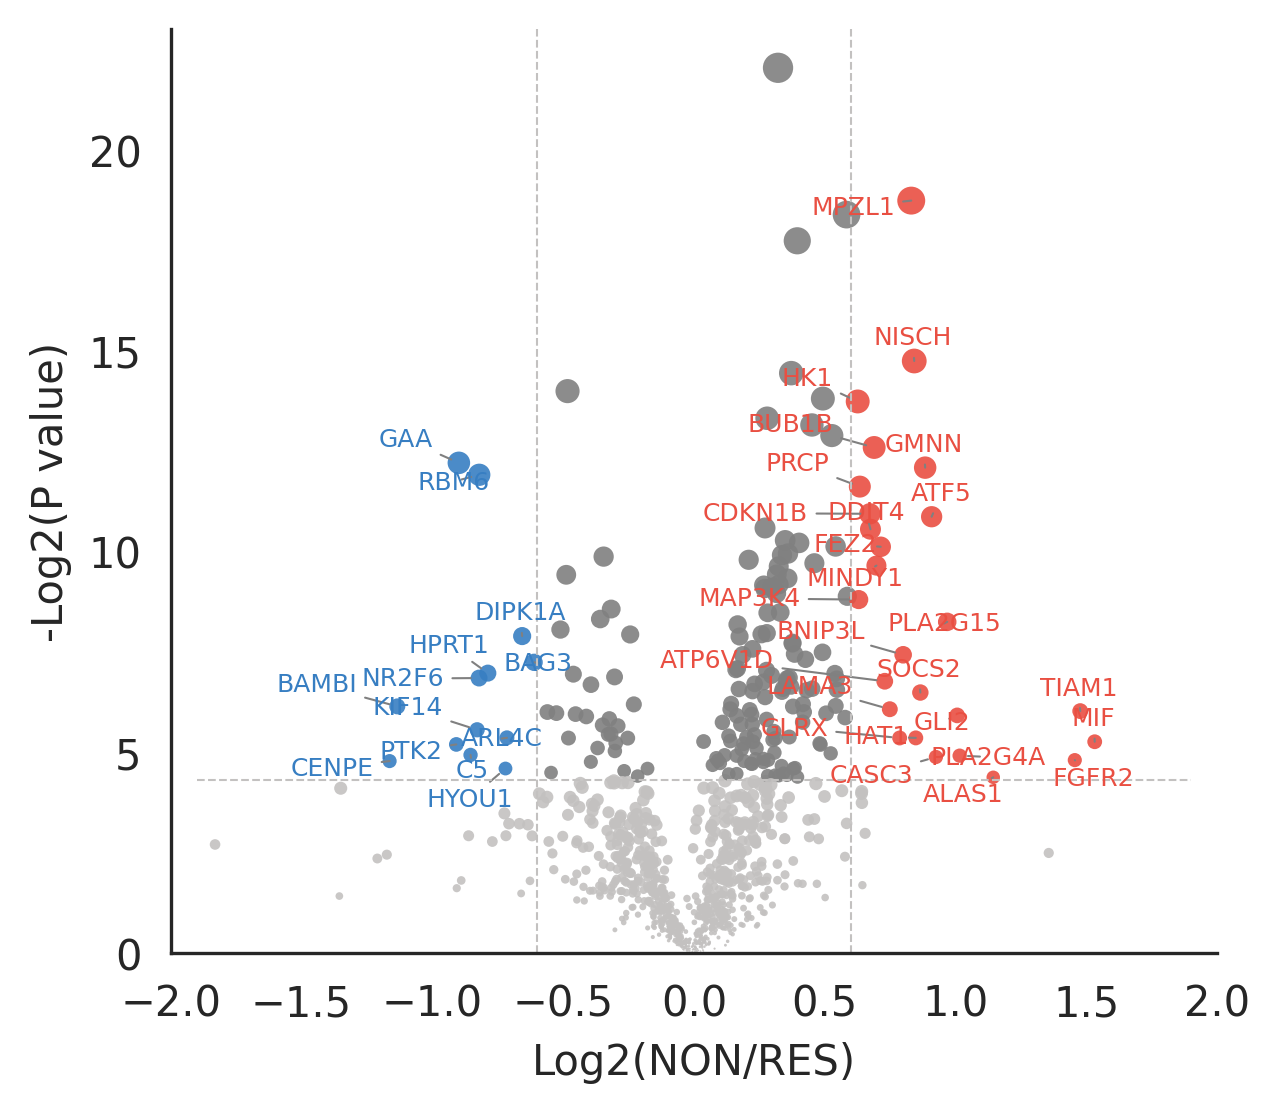

In [148]:
result = pd.DataFrame()
result['x'] = np.log2(pd_df['NON/RES'])
result['y'] = -np.log2(pd_df['P-value'])

x_threshold= 0.6 
y_threshold= -np.log2(0.05)

result['group'] = 'grey'
result.loc[(result.x > x_threshold)&(result.y > y_threshold),'group'] = '#E94F42'
result.loc[(result.x < -x_threshold)&(result.y > y_threshold),'group'] = '#377EC2'
result.loc[result.y < y_threshold,'group'] = '#C3C1C0'
print(result.head())

xmin=-2
xmax=2
ymin=0
ymax=23

fig = plt.figure(dpi=300,figsize=(4.5, 4))
ax = fig.add_subplot()
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), title='')
ax.scatter(result['x'], result['y'], s=result['y']*2.4, c=result['group'], alpha=0.9, linewidths=0)
ax.set_ylabel('-Log2(P value)')
ax.set_xlabel('Log2(NON/RES)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.vlines(-x_threshold, ymin, ymax, color='#C3C1C0',linestyle='dashed', linewidth=0.5)
ax.vlines(x_threshold, ymin, ymax, color='#C3C1C0',linestyle='dashed', linewidth=0.5)
ax.hlines(y_threshold, xmin+0.1, xmax-0.1, color='#C3C1C0',linestyle='dashed', linewidth=0.5)

texts = []
for i, row in result.iterrows():
    if row['group'] != 'grey' and row['group'] != '#C3C1C0':
        text = ax.text(row['x'], row['y'], str(i), fontsize=6, ha='right', va='bottom', color=row['group'])
        texts.append(text)

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.grid(False)

# fig.savefig('figs/volcano_attention_ctl_non&res.svg',dpi=600,format='svg', bbox_inches='tight')

plt.show()

# Distribution of average ddifferential expression：non-response v.s. response

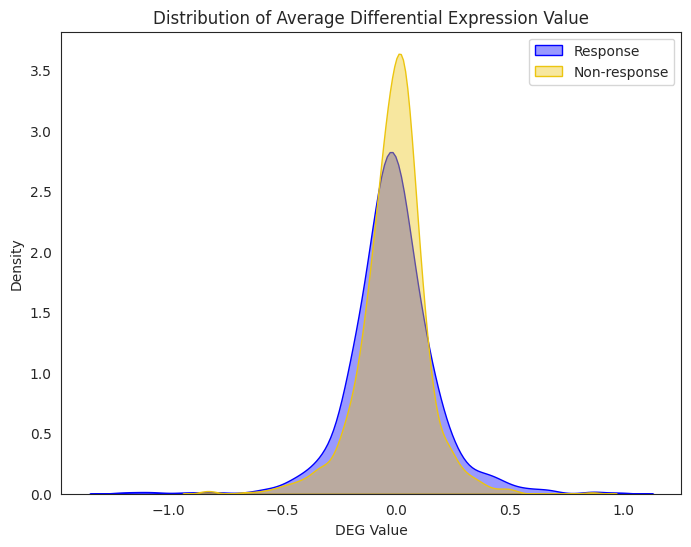

: 

In [ ]:
deg_adata = select_adata.copy()
deg_adata.X = select_adata.X - select_adata.obsm["X_ctl"]

x1 = deg_adata[deg_adata.obs["Response group"] == "Response"].X.mean(axis=0)
x2 = deg_adata[deg_adata.obs["Response group"] == "Non-response"].X.mean(axis=0)

sns.set_style("white")

plt.figure(figsize=(8, 6))

sns.kdeplot(x1, label="Response", fill=True, alpha=0.4, color="blue")
sns.kdeplot(x2, label="Non-response", fill=True, alpha=0.4, color="#ECC50F")

plt.legend()
plt.title("Distribution of Average Differential Expression Value")
plt.xlabel("DEG Value")
plt.ylabel("Density")

# plt.savefig('figs/deg_distribution_of_non&res.svg',dpi=600,format='svg')

plt.show()